<a href="https://colab.research.google.com/github/angievig/CyED3/blob/main/CFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a CFG using pyformlang

There are two ways to build a CFG using the library let's take a look to both.

The following examples construct in pyformlang a grammar that generates the language $a^*b^*$. The grammar is the following:

 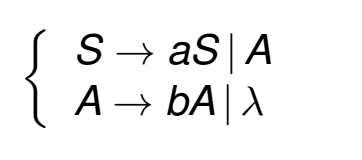

first we install the library.



In [ ]:
!pip install pyformlang

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 1.4 MB/s eta 0:00:00


## First method
The first way requires the usage of classes Production, Variable, CFG, and Epsilon so we need to import them

In [ ]:
from pyformlang.cfg import Production, Variable, Terminal, CFG, Epsilon

Now we define the grammar's variables, terminals, and produtions using the constructor methods from the Production, Variable, and Terminal classes

In [ ]:
var_S = Variable('S')
var_A = Variable('A')
ter_a = Terminal('aa')
ter_b = Terminal('bb')
prod_0 = Production(var_S,[ter_a,var_S])
prod_1 = Production(var_S,[var_A])
prod_2 = Production(var_A,[ter_b,var_A])
prod_3 = Production(var_A,[Epsilon()])


In the last step we use the CFG constructor with each of the grammars parts as follows:

In [ ]:
cfg = CFG({var_S, var_A}, {ter_a, ter_b}, var_S, {prod_0, prod_1, prod_2, prod_3})

We query if a string can be derived from the grammar as follows

In [ ]:
print(cfg.contains(['aa']))
print(cfg.contains(['aa','bb']))

True
True


## Second method
The second way is simpler as. the library is capable to obtain the elements of the grammar form a string with a special format.  This requires the usage of the pyformlang.cgf module and the CFG class, let's import them:

In [ ]:
from pyformlang.cfg import CFG

The following step is to define the grammar from the string using the `from_text` function.  To improve the readability of the grammar use a multiple line string in python enclosing your text with three quotes as shown in the code below

In [ ]:
cfg1 = CFG.from_text("""
    S -> a S | A
    A -> b A | epsilon""")

We query if a string can be derived from the grammar as follows:

In [ ]:
print(cfg1.contains('aaa'))
print(cfg1.contains('bb'))

True
True
